## ChatGPT Prompt/Response Analysis
### Data analysis is performed on a dataset with ChatGPT prompt/response conversations.

In [ ]:
# Installing dependencies
%pip install -r requirements.txt

In [261]:
# Import libraries
import re
import nltk
import textstat
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [262]:
sns.set_theme(style="whitegrid", palette="deep")

In [263]:
# Loads data from the Hugging Face platform and saves it to a dataframe
chatgpt_df = pd.read_parquet('hf://datasets/vicgalle/alpaca-gpt4/data/train-00000-of-00001-6ef3991c06080e14.parquet')

In [264]:
# Gets concise summary of the dataframe
chatgpt_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52002 entries, 0 to 52001
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   instruction  52002 non-null  str  
 1   input        52002 non-null  str  
 2   output       52002 non-null  str  
 3   text         52002 non-null  str  
dtypes: str(4)
memory usage: 85.3 MB


In [265]:
# Verifies that data has been loaded correctly
chatgpt_df.head()

,instruction,input,output,text
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....


### Finding out the most common words used in ChatGPT prompts

In [266]:
# NLTK stopwords used to filter out words that provide no or very little semantic value to text analysis (e.g., "the", "and", "is" and "in")
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shavk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [267]:
# Filters out the stop words in English
stop_words = stopwords.words('english')

In [268]:
# Function convrets given string to lower case and removes all characters except letters and spaces
def clean_text(content):
  lower_cased = str(content).lower()
  text = re.sub(r'[^a-z\s]', '', lower_cased)
  return text

In [269]:
# Applies the clean_text() function to data in the instruction column
cleaned_text = chatgpt_df['instruction'].apply(clean_text)

In [270]:
# Joins strings in series object into one string variable
convereted = ' '.join(cleaned_text)

In [271]:
# WordCloud package to generate visual word clouds, to display the most frequently used words
wordcloud = WordCloud(width=1400, height=800, stopwords=stop_words).generate(convereted)

(np.float64(-0.5), np.float64(1399.5), np.float64(799.5), np.float64(-0.5))

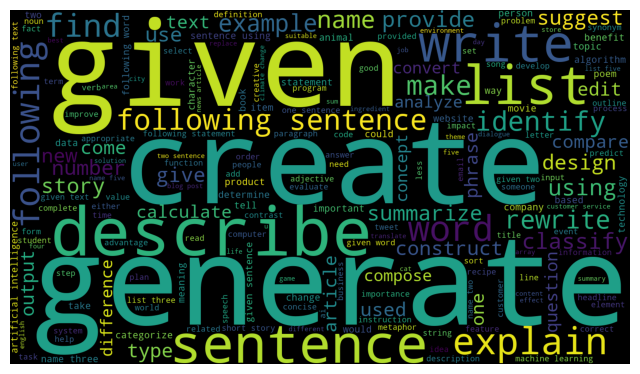

In [272]:
# Visualize wordcloud as an image
plt.figure(figsize=(8, 5))
plt.imshow(wordcloud)
plt.axis('off')

### Classification of ChatGPT prompt types

In [273]:
# Function creates prompt categories based on certain words used in prompts
def categorize_prompt(text):
  lowered = text.lower()
  if lowered.startswith(('can you', 'could you', 'would you', 'do you', 'did you', 'have you', 'is it', 'are there', 'should i')):
    return 'Question'
  elif lowered.startswith(('write', 'create', 'generate', 'compose', 'draft', 'design', 'summarize', 'scetch')):
    return 'Creative Task'
  elif lowered.startswith(('explain', 'describe', 'define', 'clarify', 'elaborate')):
    return 'Explanation'
  elif lowered.startswith(('calculate', 'solve', 'compute', 'evaluate', 'find the value')):
    return 'Problem Solving'
  elif lowered.startswith(('give', 'list', 'provide', 'name', 'mention', 'outline', 'state')):
    return 'Listing Task'
  elif lowered.startswith(('suggest', 'recommend', 'advice', 'tips for', 'ways to')):
    return 'Advice'
  elif lowered.startswith(('rewrite', 'rephrase', 'improve', 'edit', 'correct', 'fix')):
    return 'Editing/Rewriting'
  elif lowered.startswith(('classify', 'categorize', 'group the following', 'label the following')):
    return 'Classification'
  else:
    return 'Other'

In [274]:
# Removes any leading, and trailing whitespaces in the instruction column data
chatgpt_df['instruction'] = chatgpt_df['instruction'].str.strip()

In [275]:
# Applies the categorize_prompt() function to categorize and saves the values in a new column
chatgpt_df['prompt_type'] = chatgpt_df['instruction'].apply(categorize_prompt)

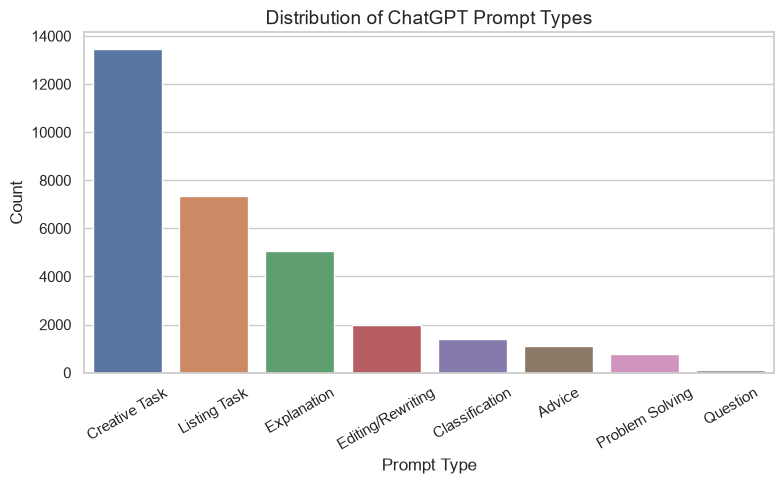

In [276]:
# Coverts series to a dataframe, assigns column lables and visualizes data in a bar chart 
prompt_counts = chatgpt_df['prompt_type'].value_counts()[1:].reset_index()
prompt_counts.columns = ['Prompt Type', 'Count']


plt.figure(figsize=(8, 5))

sns.barplot(
    data=prompt_counts,
    x='Prompt Type',
    y='Count',
    hue='Prompt Type',
    legend=False
)

plt.title('Distribution of ChatGPT Prompt Types', fontsize=14)
plt.xlabel('Prompt Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Discover the readability levels of ChatGPT responses using the Textstat library, that calculates statistics from text.

In [277]:
# Gets readability level score of ChatGPT response using Textstat library, saves it in a new column
chatgpt_df['flesch_score'] = chatgpt_df['output'].apply(textstat.flesch_reading_ease)

In [278]:
# Function categorizes readability score to six groups based on level
def readability_level(score):
  if score >= 90:
    return 'Very easy'
  elif score >= 60:
    return 'Easy'
  elif score >= 30:
    return 'Medium'
  elif score >= 10:
    return 'Difficult'
  elif score >= 0:
    return 'Very difficult'
  else:
    return "Extremely difficult"
  

In [279]:
# Applies the readability_level() function to categorize and saves the values in a new column
chatgpt_df['readability_level'] = chatgpt_df['flesch_score'].apply(readability_level)

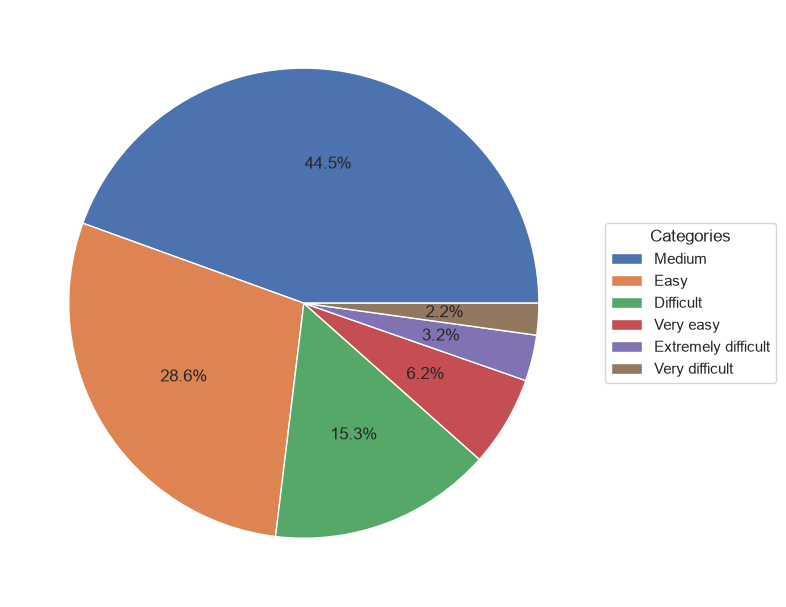

In [280]:
# Visualizes data in a pie chart 

readability_counts = chatgpt_df['readability_level'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    readability_counts,
    labels=None,
    autopct='%1.1f%%'    
)

ax.legend(
    wedges,
    readability_counts.index,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

### Prompt Length .vs Readability

In [281]:
# Counts the number of words in prompts (instructions) and saves the number in new column
chatgpt_df['instruction_word_count'] = chatgpt_df['instruction'].apply(lambda x: len(x.split(' ')))

In [282]:
# Finds equation of the regression line using Numpy's polyfit()
np.polyfit(chatgpt_df['instruction_word_count'], chatgpt_df['flesch_score'], 1)

array([ 0.19079426, 47.16412408])

In [283]:
# Shows the correlation value between columns 
chatgpt_df['instruction_word_count'].corr(chatgpt_df['flesch_score'])

np.float64(0.021566631055571012)

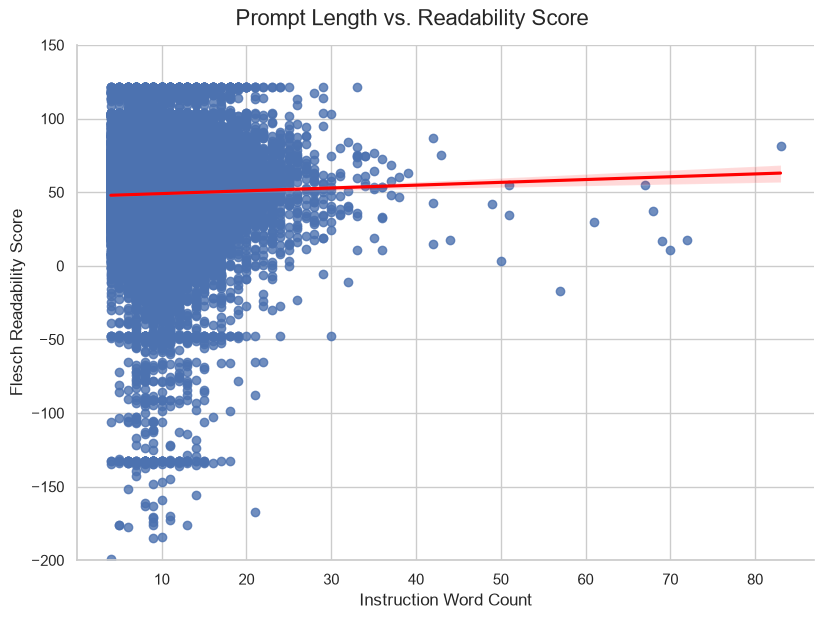

In [284]:
# Uses Seaborn's linear model plot - lmplot() that creates a scatter plot and overlays a linear regression model fit.

g = sns.lmplot(data=chatgpt_df, x='instruction_word_count', y='flesch_score', line_kws={'color':'red'}, height=6, aspect=1.4)
g.set_axis_labels(
    "Instruction Word Count",
    "Flesch Readability Score"
)

g.fig.suptitle(
    "Prompt Length vs. Readability Score",
    y=1.03,
    fontsize=16
)
# Uses Matplotlib ylim() function to disregard extreme outliers
plt.ylim(-200, 150)
plt.show()

### The verbosity of ChatGPT responses

In [285]:
# Function counts the number of sentences in ChatGPT responses
def count_sentences(text):
  text = str(text)
  sentences = re.split(r'[.!?]', text)
  sentences = [s.strip() for s in sentences if s.strip()]
  return len(sentences)

In [286]:
# Gets the number of sentences in ChatGPT responses and saves them in a new column
chatgpt_df['sentence_count'] = chatgpt_df['output'].apply(count_sentences)

In [287]:
# Gets the number of words in ChatGPT responses and saves it in a new column
chatgpt_df['output_word_count'] = chatgpt_df['output'].apply(lambda x: len(x.split()))

In [288]:
# Gets the number of words per sentence and saves it in a new column
chatgpt_df['words_per_sentence'] = chatgpt_df['output_word_count'] / chatgpt_df['sentence_count']

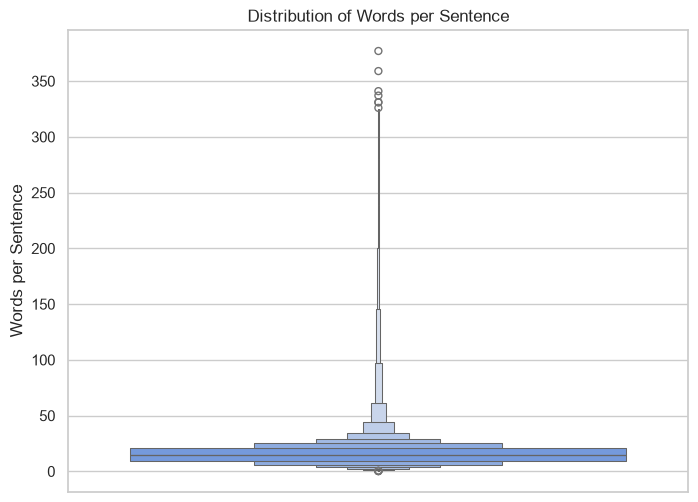

In [289]:
# Visualizes the distribution of words per sentence in a box plot

plt.figure(figsize=(8,6))

sns.boxenplot(
    y=chatgpt_df["words_per_sentence"],
    color="cornflowerblue"
)

plt.title("Distribution of Words per Sentence")
plt.ylabel("Words per Sentence")

plt.show()

### Find effect of adding extra content in prompts on ChatGPT responses

In [290]:
# Finds out whether prompt has extra content or not (input column), saves the result in a new column
chatgpt_df['has_input'] = chatgpt_df['input'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1)

In [291]:
# Creates a new dataframe to compare average ChatGPT response word counts and flesch 
# score in two categories: prompts with extra content .vs without extra content
comparision = chatgpt_df.groupby(['has_input'])[['output_word_count', 'flesch_score']].mean().reset_index()

In [292]:
# Adds extra column to distinguish two categoris - with or without extra content
comparision['Context'] = comparision['has_input'].map({0:'No extra content', 1:'Extra content'})
comparision

,has_input,output_word_count,flesch_score,Context
0,0,138.477125,46.355954,No extra content
1,1,66.073359,53.211004,Extra content


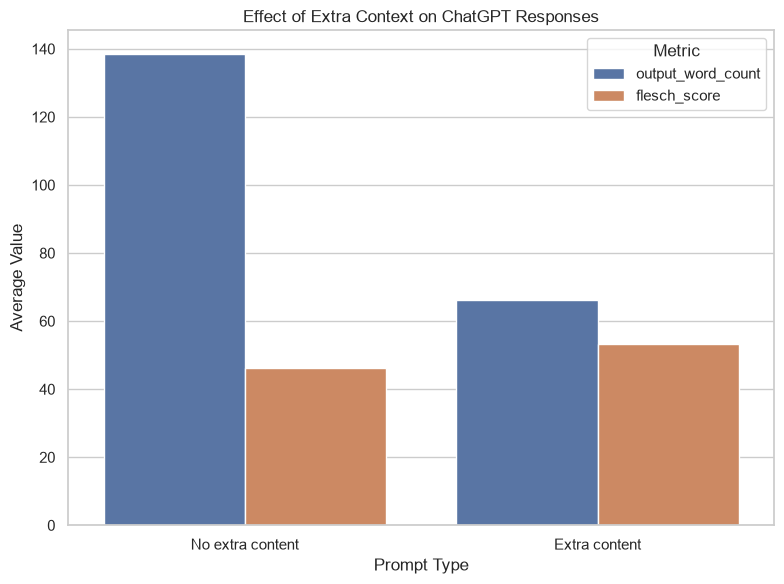

In [293]:
# Visualizes the effect of extra content on ChatGPT responses in a bar chart

comparison_long = comparision.melt(
    id_vars='Context',
    value_vars=['output_word_count', 'flesch_score'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=comparison_long,
    x='Context',
    y='Value',
    hue='Metric'
)

plt.title('Effect of Extra Context on ChatGPT Responses')
plt.xlabel('Prompt Type')
plt.ylabel('Average Value')

plt.tight_layout()
plt.show()